In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [2]:
model.invoke("hello world").content

'Hello there! How can I help you today? 😊'

### **Pydantic Schema**

In [4]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic:str = Field(description = "The topic of the post")
    post:str = Field(description = "The caption for the linkedin post")
    curated_post: str = Field(description = "The The curated caption for the linkedin post")

demo_obj = graph_schema(
    topic = "Indian Independence Day",
    post = "make content",
    curated_post = "make curated content"
)

In [5]:
demo_obj

graph_schema(topic='Indian Independence Day', post='make content', curated_post='make curated content')

In [7]:
def create_post(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a linkedin post on {topic}").content

    state.post = post

    return state

In [23]:
def curate_post(state:graph_schema) -> graph_schema:
    post = state.post

    curated_post = model.invoke(f"Curate the given post in a more professional tone: {post}").content

    state.curated_post = curated_post

    return state

In [24]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

In [25]:
pydanticGraph = graph.compile()

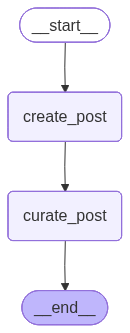

In [26]:
from IPython.display import Image, display

Image(pydanticGraph.get_graph().draw_mermaid_png())

In [27]:
pydanticGraph.invoke(
    {"topic":"Indian Independence Day","post":"","curated_post":""}
)

{'topic': 'Indian Independence Day',
 'post': "Here are a few options for a LinkedIn post on Indian Independence Day, ranging in tone and focus. Choose the one that best suits your personal brand and network:\n\n---\n\n**Option 1: Reflective and Forward-Looking**\n\n**Headline:** Celebrating India's Independence: A Journey of Resilience and Progress 🇮🇳\n\n**Body:**\n\nToday, as India celebrates its 77th Independence Day, I'm filled with immense pride and a deep sense of gratitude. This day marks not just a historical milestone, but a testament to the unwavering spirit of our people, their sacrifices, and their relentless pursuit of freedom and progress.\n\nFrom its nascent beginnings to its current standing on the global stage, India's journey has been one of incredible resilience, innovation, and a constant striving for a brighter future. It's a nation built on the dreams of many, and it continues to evolve, driven by the aspirations of its diverse and dynamic population.\n\nOn this a